<h1 style="text-align:center;">Assignment - 01</h1>

## Libraries

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

## Data Loading and info.

In [2]:
df = pd.read_csv('dataset.csv')

## Bi-Partite Graph

In [3]:
# Create bipartite network
# Actors and Movies as different node types, edges weighted by rating
G = nx.Graph()

# Add nodes with bipartite attribute
actors = df['Actor'].unique()
movies = df['Film'].unique()

print(f"Dataset contains {len(actors)} unique actors and {len(movies)} unique movies")

# Add actor nodes (bipartite=0)
for actor in actors:
    G.add_node(actor, bipartite=0, node_type='actor')

# Add movie nodes (bipartite=1) 
for movie in movies:
    G.add_node(movie, bipartite=1, node_type='movie')

# Add edges between actors and movies with rating as weight
for _, row in df.iterrows():
    G.add_edge(row['Actor'], row['Film'], weight=row['Rating'], year=row['Year'], votes=row['Votes'])


Dataset contains 15 unique actors and 105 unique movies


## Graph Contains

In [4]:
print(f"\nBipartite network created with:")
print(f"- {len(actors)} actor nodes")
print(f"- {len(movies)} movie nodes") 
print(f"- {G.number_of_edges()} actor-movie connections")

# Verify bipartite structure
print(f"Is bipartite: {nx.is_bipartite(G)}")


Bipartite network created with:
- 15 actor nodes
- 105 movie nodes
- 105 actor-movie connections
Is bipartite: True


## OverAll Network Analysis

In [5]:
print("\n=== NETWORK ANALYSIS ===")

actor_degrees = [(node, degree) for node, degree in G.degree() if G.nodes[node]['node_type'] == 'actor']
movie_degrees = [(node, degree) for node, degree in G.degree() if G.nodes[node]['node_type'] == 'movie']

top_actors = sorted(actor_degrees, key=lambda x: x[1], reverse=True)[:10]
top_movies = sorted(movie_degrees, key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Most Active Actors (by number of movies):")
for actor, degree in top_actors:
    print(f"{actor}: {degree} movies")


=== NETWORK ANALYSIS ===

Top 10 Most Active Actors (by number of movies):
Fred Astaire: 7 movies
Lauren Bacall: 7 movies
Brigitte Bardot: 7 movies
John Belushi: 7 movies
Ingmar Bergman: 7 movies
Ingrid Bergman: 7 movies
Humphrey Bogart: 7 movies
Marlon Brando: 7 movies
Richard Burton: 7 movies
James Cagney: 7 movies


## Top 5 Edge Degrees

In [6]:
actor_weighted_degrees = {}
movie_weighted_degrees = {}

for node in G.nodes():
    weighted_degree = sum([G[node][neighbor]['weight'] for neighbor in G.neighbors(node)])
    if G.nodes[node]['node_type'] == 'actor':
        actor_weighted_degrees[node] = weighted_degree
    else:
        movie_weighted_degrees[node] = weighted_degree

top_rated_actors = sorted(actor_weighted_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Actors by Total Rating Score:")
for actor, total_rating in top_rated_actors:
    avg_rating = total_rating / dict(G.degree())[actor]
    print(f"{actor}: Total={total_rating:.1f}, Average={avg_rating:.2f}")


Top 5 Actors by Total Rating Score:
Humphrey Bogart: Total=51.4, Average=7.34
Ingmar Bergman: Total=50.7, Average=7.24
James Dean: Total=50.4, Average=7.20
James Cagney: Total=47.6, Average=6.80
Gary Cooper: Total=47.4, Average=6.77


## Results after removing Top 5 actor Nodes

In [7]:
G_robust = G.copy()
top_5_actors = [actor for actor, degree in top_actors[:5]]
G_robust.remove_nodes_from(top_5_actors)
components_after = nx.number_connected_components(G_robust)
remaining_actors = len([n for n in G_robust.nodes() if G_robust.nodes[n]['node_type'] == 'actor'])
remaining_movies = len([n for n in G_robust.nodes() if G_robust.nodes[n]['node_type'] == 'movie'])

print(f"\nRobustness Test - After removing top 5 actors:")
print(f"Remaining actors: {remaining_actors}")
print(f"Remaining movies: {remaining_movies}")
print(f"Connected components: {components_after}")


Robustness Test - After removing top 5 actors:
Remaining actors: 10
Remaining movies: 105
Connected components: 45


## Top 5 Highest Weighted Edges

In [8]:
edge_ratings = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]
top_rated_connections = sorted(edge_ratings, key=lambda x: x[2], reverse=True)[:5]
print("\nTop 5 Highest Rated Actor-Movie Connections:")
for actor, movie, rating in top_rated_connections:
    # Determine which is actor and which is movie
    if G.nodes[actor]['node_type'] == 'actor':
        print(f"{actor} in '{movie}': {rating} rating")
    else:
        print(f"{movie} in '{actor}': {rating} rating")


Top 5 Highest Rated Actor-Movie Connections:
Lauren Bacall in 'Howl's Moving Castle': 8.2 rating
Ingrid Bergman in 'Autumn Sonata': 8.2 rating
Ingmar Bergman in 'Cries & Whispers': 8.1 rating
Lauren Bacall in 'Ernest & Celestine': 7.9 rating
John Belushi in 'The Blues Brothers': 7.9 rating


## Removing low weighted Edges (rating < 6.0)

In [9]:
G_filtered = G.copy()
low_rated_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 6.0]
G_filtered.remove_edges_from(low_rated_edges)
print(f"\nAfter removing edges with rating < 6.0:")
print(f"Remaining edges: {G_filtered.number_of_edges()} (removed {len(low_rated_edges)})")
print(f"Connected components: {nx.number_connected_components(G_filtered)}")



After removing edges with rating < 6.0:
Remaining edges: 72 (removed 33)
Connected components: 48


## Overall Graph

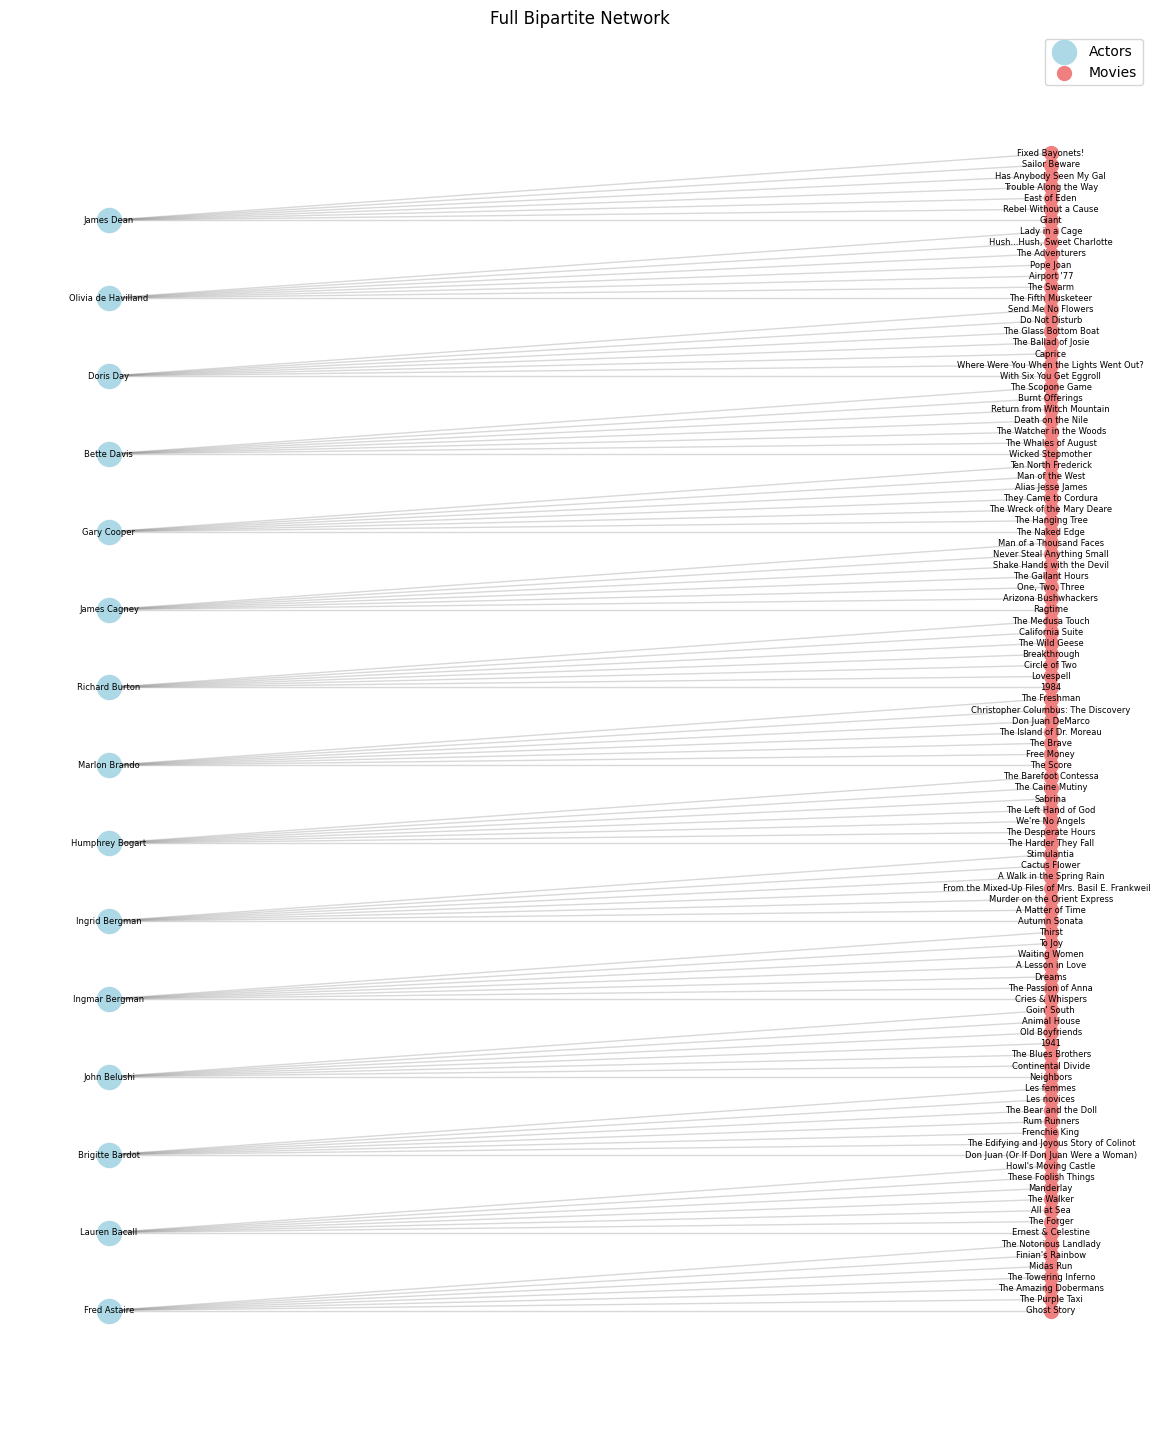

In [10]:
plt.figure(figsize=(50, 40))

plt.subplot(2, 3, 1)
actor_nodes = [n for n in G.nodes() if G.nodes[n]['node_type'] == 'actor']
movie_nodes = [n for n in G.nodes() if G.nodes[n]['node_type'] == 'movie']

pos = {}
# Position actors on the left, movies on the right
for i, actor in enumerate(actor_nodes):
    pos[actor] = (0, i)
for i, movie in enumerate(movie_nodes):
    pos[movie] = (2, i * len(actor_nodes) / len(movie_nodes))

nx.draw_networkx_nodes(G, pos, nodelist=actor_nodes, node_color='lightblue', 
                       node_size=300, label='Actors')
nx.draw_networkx_nodes(G, pos, nodelist=movie_nodes, node_color='lightcoral', 
                       node_size=100, label='Movies')
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=6)
plt.title("Full Bipartite Network")
plt.legend()
plt.axis('off')

plt.savefig("bipartite_network.png", dpi=300, bbox_inches="tight")

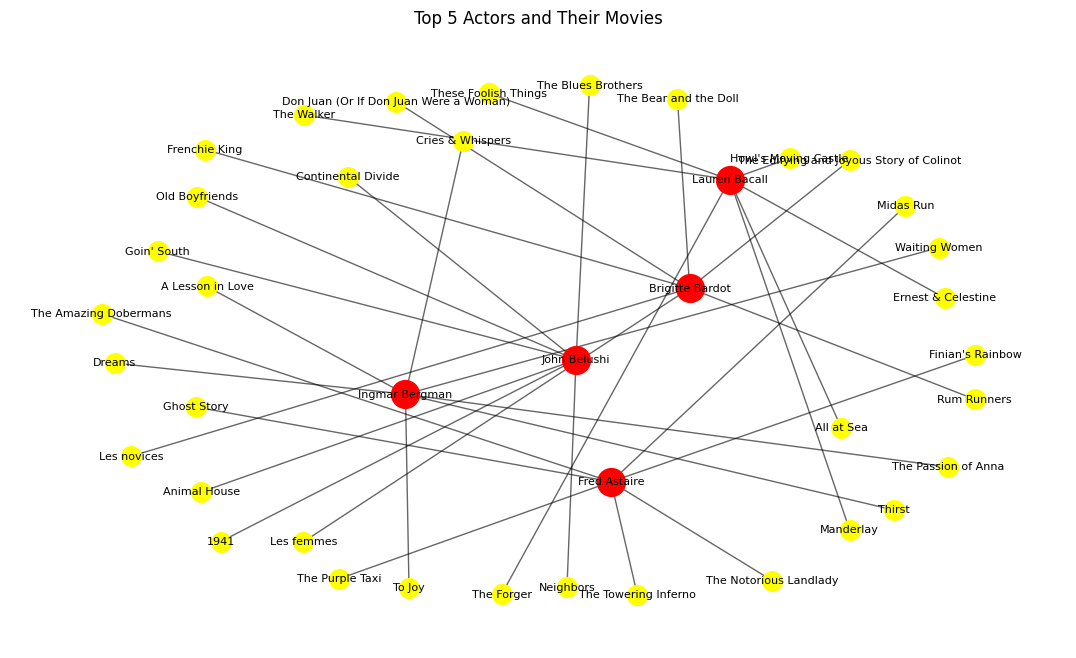

In [11]:
plt.figure(figsize=(30, 8)) 
plt.subplot(1, 2, 1)
top_5_actor_names = [actor for actor, degree in top_actors[:5]]
top_actor_subgraph = G.subgraph(top_5_actor_names + 
                                [neighbor for actor in top_5_actor_names 
                                 for neighbor in G.neighbors(actor)])

actor_sub = [n for n in top_actor_subgraph.nodes() if G.nodes[n]['node_type'] == 'actor']
movie_sub = [n for n in top_actor_subgraph.nodes() if G.nodes[n]['node_type'] == 'movie']

pos2 = nx.spring_layout(top_actor_subgraph, k=3, iterations=50)
nx.draw_networkx_nodes(top_actor_subgraph, pos2, nodelist=actor_sub, 
                       node_color='red', node_size=400)
nx.draw_networkx_nodes(top_actor_subgraph, pos2, nodelist=movie_sub, 
                       node_color='yellow', node_size=200)
nx.draw_networkx_edges(top_actor_subgraph, pos2, alpha=0.6)
nx.draw_networkx_labels(top_actor_subgraph, pos2, font_size=8)
plt.title("Top 5 Actors and Their Movies")
plt.axis('off')


plt.savefig("top5_with_movies.png", dpi=300, bbox_inches="tight")

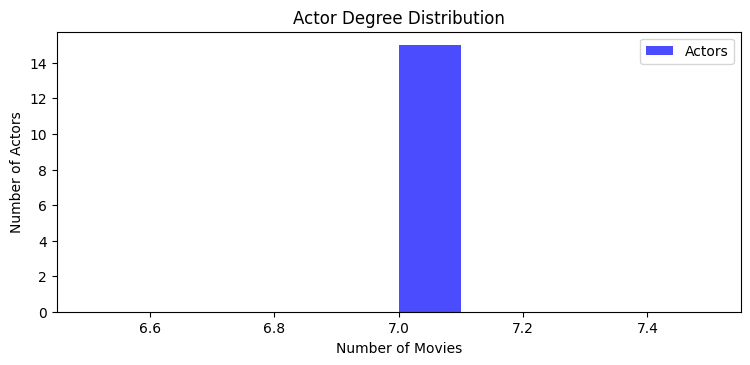

In [12]:
plt.figure(figsize=(30, 8))
plt.subplot(2, 3, 3)
actor_degree_values = [degree for actor, degree in actor_degrees]
plt.hist(actor_degree_values, bins=10, alpha=0.7, color='blue', label='Actors')
plt.xlabel('Number of Movies')
plt.ylabel('Number of Actors')
plt.title('Actor Degree Distribution')
plt.legend()

plt.savefig("actors_degree.png", dpi=300, bbox_inches="tight")

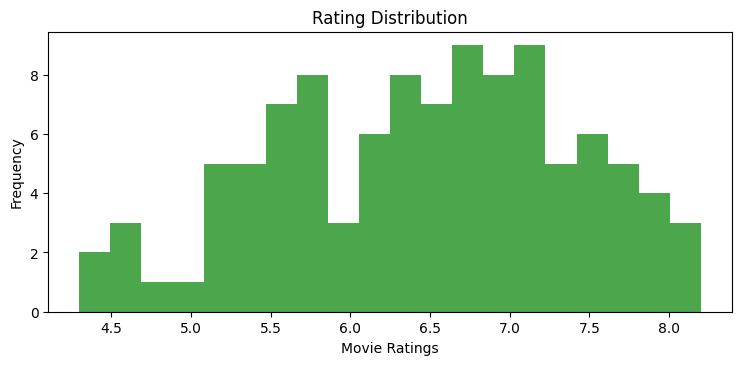

In [13]:
plt.figure(figsize=(30, 8))
plt.subplot(2, 3, 4)
ratings = [d['weight'] for u, v, d in G.edges(data=True)]
plt.hist(ratings, bins=20, alpha=0.7, color='green')
plt.xlabel('Movie Ratings')
plt.ylabel('Frequency')
plt.title('Rating Distribution')

plt.savefig("edge_represents.png", dpi=300, bbox_inches="tight")

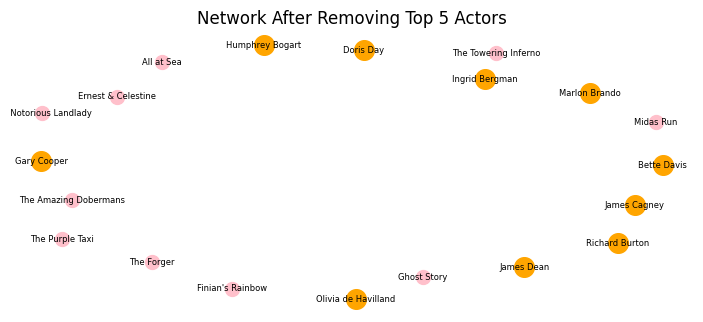

In [14]:
plt.figure(figsize=(30, 8))
plt.subplot(2, 3, 5)
if nx.number_connected_components(G_robust) > 0:
    remaining_actor_nodes = [n for n in G_robust.nodes() if G_robust.nodes[n]['node_type'] == 'actor']
    remaining_movie_nodes = [n for n in G_robust.nodes() if G_robust.nodes[n]['node_type'] == 'movie']
    
    if len(remaining_actor_nodes) > 0 and len(remaining_movie_nodes) > 0:
        # Sample for visualization if too many nodes
        sample_size = min(20, len(remaining_actor_nodes) + len(remaining_movie_nodes))
        sample_nodes = (remaining_actor_nodes[:min(10, len(remaining_actor_nodes))] + 
                       remaining_movie_nodes[:min(10, len(remaining_movie_nodes))])
        
        G_robust_sample = G_robust.subgraph(sample_nodes)
        pos3 = nx.spring_layout(G_robust_sample, k=2, iterations=50)
        
        sample_actors = [n for n in G_robust_sample.nodes() if G_robust.nodes[n]['node_type'] == 'actor']
        sample_movies = [n for n in G_robust_sample.nodes() if G_robust.nodes[n]['node_type'] == 'movie']
        
        nx.draw_networkx_nodes(G_robust_sample, pos3, nodelist=sample_actors, 
                               node_color='orange', node_size=200)
        nx.draw_networkx_nodes(G_robust_sample, pos3, nodelist=sample_movies, 
                               node_color='pink', node_size=100)
        nx.draw_networkx_edges(G_robust_sample, pos3, alpha=0.5)
        nx.draw_networkx_labels(G_robust_sample, pos3, font_size=6)

plt.title("Network After Removing Top 5 Actors")
plt.axis('off')

plt.savefig("top5_without_actors.png", dpi=300, bbox_inches="tight")

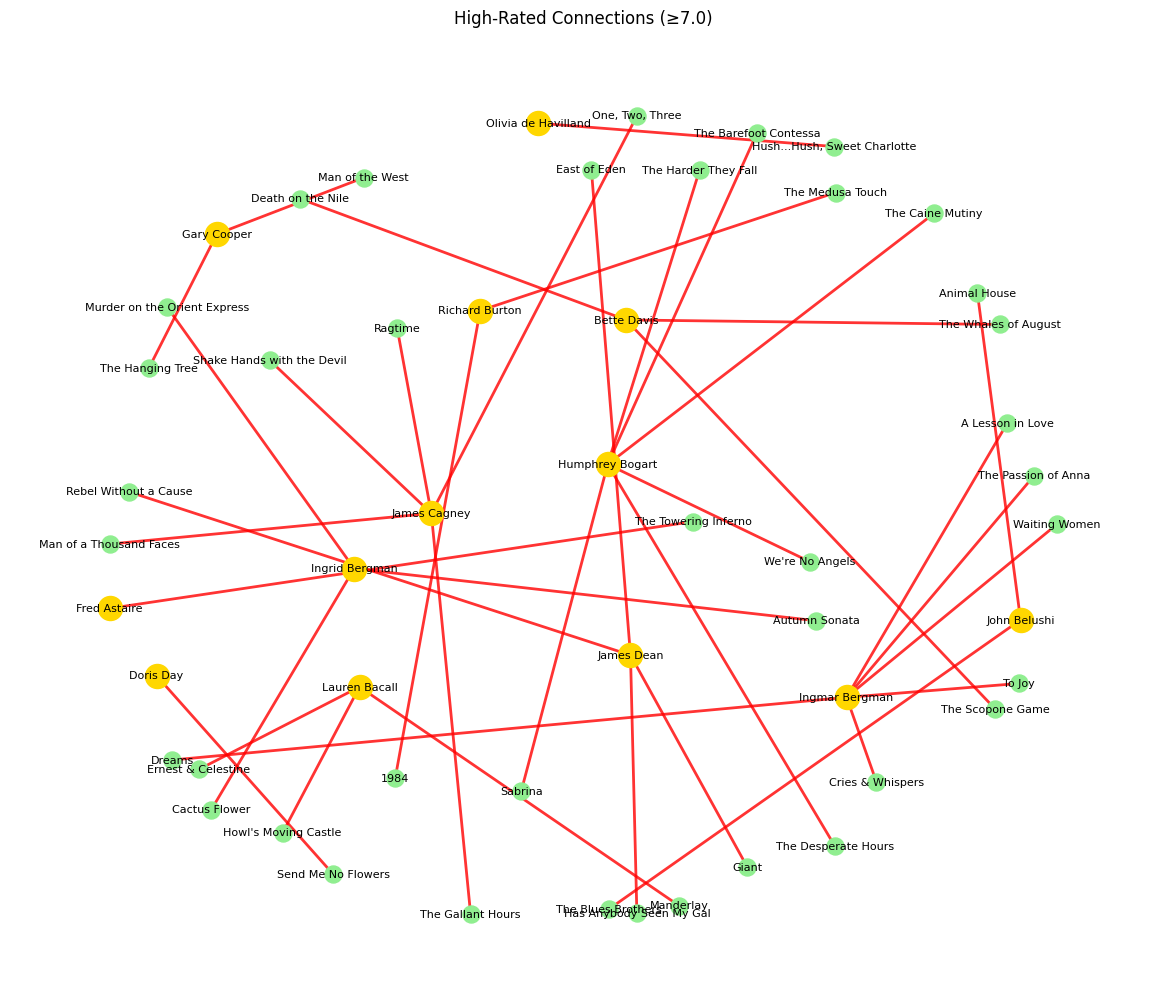

In [15]:
plt.figure(figsize=(35,20))
plt.subplot(2, 3, 6)
high_rated_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= 7.0]
G_high_rated = G.edge_subgraph(high_rated_edges)

if G_high_rated.number_of_nodes() > 0:
    hr_actors = [n for n in G_high_rated.nodes() if G.nodes[n]['node_type'] == 'actor']
    hr_movies = [n for n in G_high_rated.nodes() if G.nodes[n]['node_type'] == 'movie']
    
    pos4 = nx.spring_layout(G_high_rated, k=2, iterations=50)
    nx.draw_networkx_nodes(G_high_rated, pos4, nodelist=hr_actors, 
                           node_color='gold', node_size=300)
    nx.draw_networkx_nodes(G_high_rated, pos4, nodelist=hr_movies, 
                           node_color='lightgreen', node_size=150)
    nx.draw_networkx_edges(G_high_rated, pos4, alpha=0.8, edge_color='red', width=2)
    nx.draw_networkx_labels(G_high_rated, pos4, font_size=8)

plt.title("High-Rated Connections (≥7.0)")
plt.axis('off')

plt.tight_layout()
plt.show()

<h1 style="text-align:center;">THE END</h1>